# Crypto Strategy — Results Notebook

Runs the full pipeline via `run_pipeline`, then visualizes equity curves
(in-sample vs out-of-sample), the metrics table, and the null-test
distribution. **Read `HONEST_ASSESSMENT.md` for the interpretation** — the
short version is that the strategy does not beat buy-and-hold after costs and
loses money out-of-sample.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from crypto_research.config import Config
from run_backtest import run_pipeline, _metrics_for
from crypto_research.backtest.walkforward import split_is_oos
from crypto_research.backtest.nulltest import run_null_test

cfg = Config.load('../config/config.yaml')
R = run_pipeline(cfg)
bt = R['backtest']
oos_start = cfg.backtest.oos_start
print('Combiner:', R['combiner'].name)
print('News available:', R['features'].attrs['news_available'])

Combiner: rules
News available: False


## Equity curves — strategy vs benchmarks (OOS period shaded)

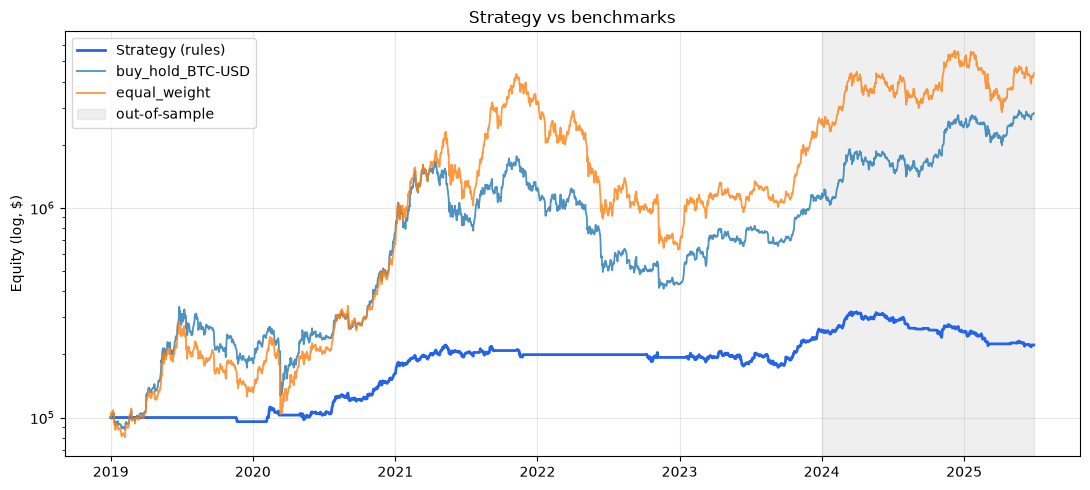

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(bt.equity.index, bt.equity.values, label=f"Strategy ({R['combiner'].name})", lw=2, color='#2563eb')
for name, b in R['benchmarks'].items():
    ax.plot(b.equity.index, b.equity.values, label=name, lw=1.3, alpha=0.8)
cutoff = pd.Timestamp(oos_start, tz='UTC')
ax.axvspan(cutoff, bt.equity.index.max(), color='grey', alpha=0.12, label='out-of-sample')
ax.set_yscale('log'); ax.set_ylabel('Equity (log, $)'); ax.set_title('Strategy vs benchmarks')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Metrics table — full sample, in-sample, out-of-sample

In [3]:
rows = {}
is_r, oos_r = split_is_oos(bt.returns, oos_start)
rows['strategy_full'] = _metrics_for(bt.returns, cfg, bt.turnover).as_dict()
rows['strategy_IS'] = _metrics_for(is_r, cfg).as_dict()
rows['strategy_OOS'] = _metrics_for(oos_r, cfg).as_dict()
for name, b in R['benchmarks'].items():
    b_is, b_oos = split_is_oos(b.returns, oos_start)
    rows[f'{name}_full'] = _metrics_for(b.returns, cfg, b.turnover).as_dict()
    rows[f'{name}_OOS'] = _metrics_for(b_oos, cfg).as_dict()
tbl = pd.DataFrame(rows).T[['cagr','ann_vol','sharpe','sortino','max_drawdown','hit_rate','turnover_annual']]
tbl.round(3)

,cagr,ann_vol,sharpe,sortino,max_drawdown,hit_rate,turnover_annual
strategy_full,0.130,0.175,0.787,0.876,-0.320,0.271,15.198
strategy_IS,0.209,0.171,1.195,1.298,-0.217,0.257,0.000
strategy_OOS,-0.096,0.190,-0.438,-0.526,-0.320,0.317,0.000
buy_hold_BTC-USD_full,0.673,0.649,1.122,1.530,-0.767,0.514,0.154
buy_hold_BTC-USD_OOS,0.876,0.515,1.478,2.373,-0.282,0.524,0.000
equal_weight_full,0.789,0.759,1.154,1.565,-0.855,0.527,0.256
equal_weight_OOS,0.449,0.639,0.898,1.379,-0.491,0.513,0.000


## Null test — is the strategy inside the noise band?

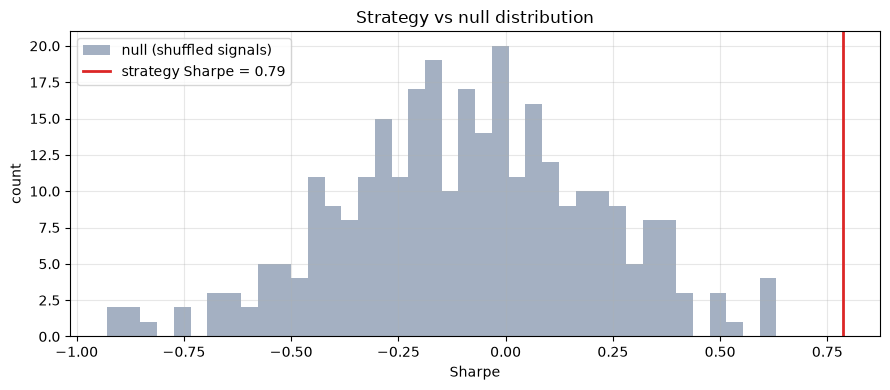

Percentile of strategy in null: 100.0
NOTE: beating a shuffle of itself is weak; the benchmark comparison above is the binding verdict.


In [4]:
null = run_null_test(
    R['panel'], R['final_weights'], cfg.backtest.initial_capital,
    cfg.backtest.cost_bps, cfg.backtest.slippage_bps,
    cfg.backtest.trading_days_per_year, n_runs=300, mode='shuffle',
    allow_short=cfg.decision.rules.allow_short,
)
strat_sharpe = _metrics_for(bt.returns, cfg).sharpe
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null.sharpe, bins=40, color='#94a3b8', alpha=0.85, label='null (shuffled signals)')
ax.axvline(strat_sharpe, color='#dc2626', lw=2, label=f'strategy Sharpe = {strat_sharpe:.2f}')
ax.set_xlabel('Sharpe'); ax.set_ylabel('count'); ax.set_title('Strategy vs null distribution')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Percentile of strategy in null:', round(null.percentile_of(strat_sharpe), 1))
print('NOTE: beating a shuffle of itself is weak; the benchmark comparison above is the binding verdict.')